# 01 — Corpus Statistics

Descriptive statistics for the Urdu Emergency Communication (UEC) pilot corpus: distribution by urgency and emergency type, utterance length, and presence rates of the lexicon-tagged features (temporal expressions, distress markers, intensifiers, negation, repetition) across urgency levels.

See `data/annotation_schema.md` for field definitions and `paper/research_report.md` for the full methodology and discussion.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import pandas as pd
import matplotlib.pyplot as plt

from src.corpus_analysis import corpus_to_dataframe

URGENCY_ORDER = ["low", "medium", "high", "critical"]

with open("../data/corpus.jsonl", encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

df = corpus_to_dataframe(records)
for field in ["temporal_expression", "distress_marker", "intensifier", "negation"]:
    df[f"{field}_present"] = df[field].apply(lambda x: x["present"])
df["repetition"] = df["repetition"].astype(bool)

print(f"{len(df)} utterances")
df.head(3)[["id", "emergency_type", "urgency", "text", "english_gloss"]]

60 utterances


,id,emergency_type,urgency,text,english_gloss
0,UEC-001,medical,low,مجھے ہلکا سا سر درد ہے، کیا میں پیناڈول لے سکت...,"I have a slight headache, can I take Panadol?"
1,UEC-002,medical,low,میری آنکھ میں ہلکی سی جلن ہو رہی ہے، کیا یہ عا...,"My eye has a slight burning sensation, is this..."
2,UEC-003,medical,low,بچے کو ہلکا سا بخار ہے، کیا ابھی ڈاکٹر کو دکھا...,"The child has a mild fever, is it necessary to..."


## Distribution by urgency and emergency type

In [2]:
print("By urgency:")
print(df["urgency"].value_counts().reindex(URGENCY_ORDER))
print("\nBy emergency type:")
print(df["emergency_type"].value_counts())
print("\nCross-tab:")
pd.crosstab(df["emergency_type"], df["urgency"])[URGENCY_ORDER]

By urgency:
urgency
low         15
medium      15
high        15
critical    15
Name: count, dtype: int64

By emergency type:
emergency_type
medical     12
accident    12
fire        12
crime       12
other       12
Name: count, dtype: int64

Cross-tab:


urgency,low,medium,high,critical
emergency_type,,,,
accident,3,3,3,3
crime,3,3,3,3
fire,3,3,3,3
medical,3,3,3,3
other,3,3,3,3


## Utterance length by urgency

urgency
low         12.47
medium      13.13
high        12.20
critical    14.33
Name: token_count, dtype: float64


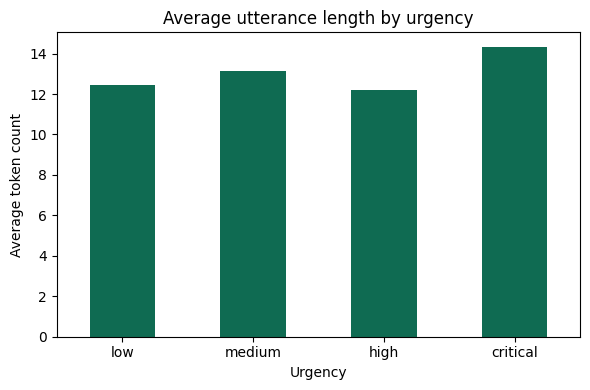

In [3]:
length_by_urgency = df.groupby("urgency")["token_count"].mean().reindex(URGENCY_ORDER)
print(length_by_urgency.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
length_by_urgency.plot(kind="bar", ax=ax, color="#0f6b52")
ax.set_ylabel("Average token count")
ax.set_xlabel("Urgency")
ax.set_title("Average utterance length by urgency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/length_by_urgency.png", dpi=150)
plt.show()

## Lexicon-tagged feature presence by urgency

The rate at which each lexicon-tagged category (temporal expressions, distress markers, intensifiers, negation) and manually-annotated repetition appears in utterances of each urgency level.

          temporal  distress  intensifier  negation  repetition
urgency                                                        
low           0.47      0.00         0.00      0.00        0.00
medium        0.40      0.07         0.07      0.13        0.00
high          0.80      0.27         0.60      0.07        0.07
critical      0.93      1.00         0.40      0.27        0.40


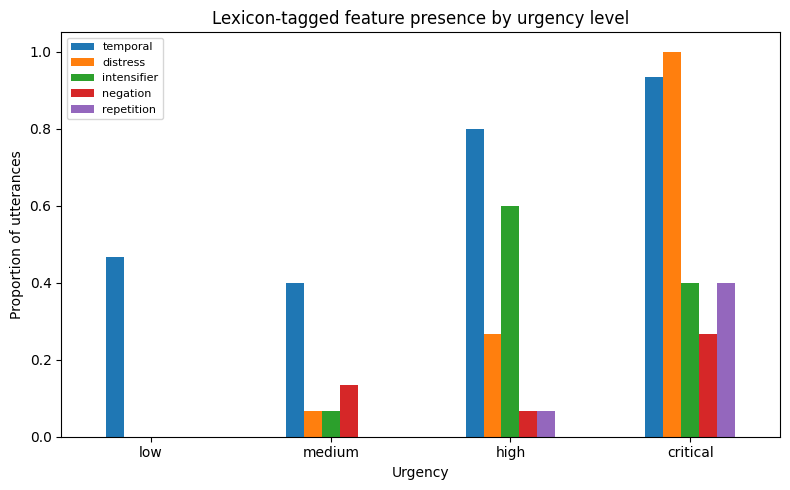

In [4]:
feature_cols = [
    "temporal_expression_present",
    "distress_marker_present",
    "intensifier_present",
    "negation_present",
    "repetition",
]
summary = df.groupby("urgency")[feature_cols].mean().reindex(URGENCY_ORDER)
summary.columns = ["temporal", "distress", "intensifier", "negation", "repetition"]
print(summary.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
summary.plot(kind="bar", ax=ax)
ax.set_ylabel("Proportion of utterances")
ax.set_xlabel("Urgency")
ax.set_title("Lexicon-tagged feature presence by urgency level")
ax.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/lexicon_features_by_urgency.png", dpi=150)
plt.show()

## Observations

- Temporal-expression and repetition presence both increase with urgency, most sharply between `high` and `critical`.
- Distress markers concentrate almost entirely in `high`/`critical` utterances, consistent with the annotation scheme's design (these lexicon items — خدا، پلیز، مدد، بچاؤ — are inherently urgency-signaling words).
- These are pilot-scale (n=60) descriptive patterns, not statistically tested claims — see the limitations section in `paper/research_report.md`.